# 1. Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pmdarima as pm
import xgboost as xgb
import joblib
import os
import time
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

# 2. Carga de Datos

In [2]:
SEED = 40
DATA_DIR = '../data/'
MODELS_DIR = '../models/'

sales = pd.read_csv(f'{DATA_DIR}sales_train_evaluation.csv')
calendar = pd.read_csv(f'{DATA_DIR}calendar.csv')

# 3. Preprocesamiento y filtrado

In [3]:
# Filtramos solo la categoría FOODS y la tienda CA_1
foods = sales[(sales['cat_id'] == 'FOODS') & (sales['store_id'] == 'CA_1')].copy()

# Columnas con demanda diaria (d_1, d_2, d3, ...)
d_cols = [c for c in foods.columns if c.startswith('d_')]
sales_data = foods[d_cols].values

# 4. Clasificación de la demanda (ADI / CV^2)

In [4]:
# Cálculo de ADI (Average Demand Interval) y CV^2
adi_list = []
cv2_list = []

for row in sales_data:
    # ADI: promedio de días entre demandas consecutivas
    nonzero = np.nonzero(row)[0]
    if len(nonzero) > 1:
        adi = np.mean(np.diff(nonzero))
    else:
        adi = len(row)

    # CV^2: (desviación estándar / media)^2 de las demandas no nulas
    nonzero_sales = row[nonzero]
    if len(nonzero_sales) > 0 and nonzero_sales.mean() != 0:
        cv2 = (nonzero_sales.std() / nonzero_sales.mean()) ** 2
    else:
        cv2 = 0

    adi_list.append(adi)
    cv2_list.append(cv2)

foods['ADI'] = adi_list
foods['CV2'] = cv2_list

# Clasificación según umbrales de Syntetos-Boylan
ADI_threshold = 1.32
CV2_threshold = 0.49

conditions = [
    (foods['ADI'] <= ADI_threshold) & (foods['CV2'] <= CV2_threshold),
    (foods['ADI'] > ADI_threshold) & (foods['CV2'] <= CV2_threshold),
    (foods['ADI'] <= ADI_threshold) & (foods['CV2'] > CV2_threshold),
    (foods['ADI'] > ADI_threshold) & (foods['CV2'] > CV2_threshold)
]
choices = ['Smooth', 'Intermittent', 'Erratic', 'Lumpy']
foods['Tipo_Demanda'] = np.select(conditions, choices, default='Unclassified')

foods['Tipo_Demanda'].value_counts()

Tipo_Demanda
Intermittent    839
Lumpy           387
Smooth          153
Erratic          58
Name: count, dtype: int64

## Gráfico de clasificación:

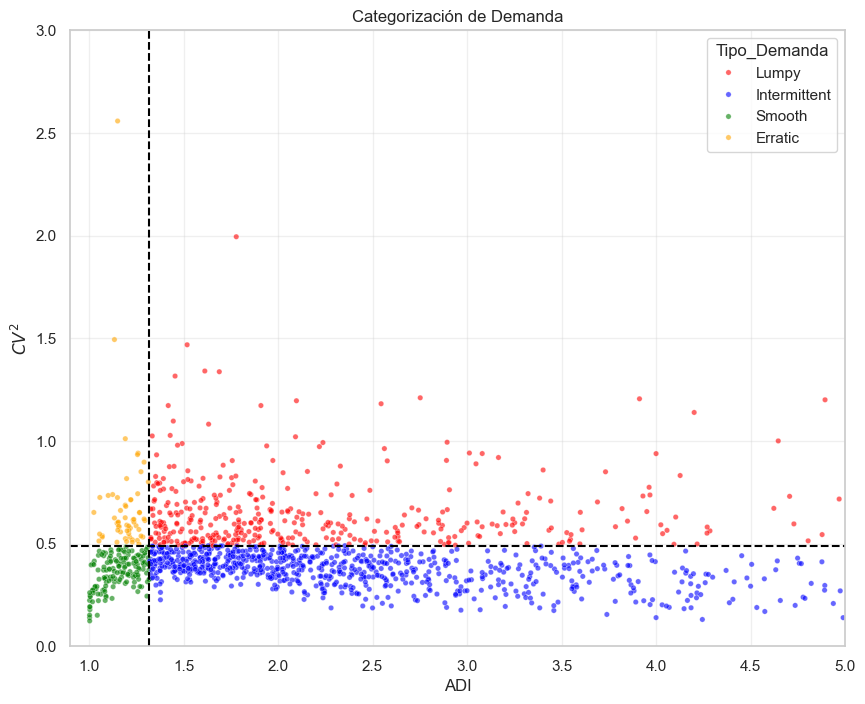

In [5]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=foods, x='ADI', y='CV2', hue='Tipo_Demanda',
                palette={'Smooth': 'green', 'Intermittent': 'blue',
                         'Erratic': 'orange', 'Lumpy': 'red'},
                alpha=0.6, s=15)

plt.axvline(x=ADI_threshold, color='black', linestyle='--')
plt.axhline(y=CV2_threshold, color='black', linestyle='--')
plt.xlim(0.9, 5)
plt.ylim(0, 3)
plt.title('Categorización de Demanda')
plt.xlabel('ADI')
plt.ylabel(r'$CV^2$')
plt.grid(True, alpha=0.3)
plt.show()

# 5. Selección de muestra y limpieza de series

In [6]:
# Selección de 10 productos 'Smooth'
smooth_products = foods[foods['Tipo_Demanda'] == 'Smooth']
n_sample = 10
sample_smooth = smooth_products.sample(n=n_sample, random_state=SEED)

ids_10_smooth = sample_smooth['id'].tolist()
items_10_smooth = sample_smooth['item_id'].tolist()

## Convertir a formato largo (melt):

In [7]:
# Melt de los 10 productos seleccionados
melted_smooth = pd.melt(
    sample_smooth,
    id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],
    value_vars=d_cols,
    var_name='d',
    value_name='sales'
)

# Cruzar con calendario para obtener fechas reales
melted_smooth = pd.merge(melted_smooth, calendar[['d', 'date']], on='d', how='left')
melted_smooth['date'] = pd.to_datetime(melted_smooth['date'])

## Filtrar "vida activa" y gaps de discontinuidad:

In [8]:
# Conservar solo la "vida activa" del producto (posterior a la primera venta)
mask_active_life = melted_smooth.groupby('id')['sales'].cumsum() > 0
melted_clean = melted_smooth[mask_active_life].copy()

# Función para recortar series con gaps largos (mayor a 180 dias ->6 meses)
def eliminar_periodos_vacios_largos(group_df, gap_threshold=180):
    group_df = group_df.sort_values('date')
    sales_days = group_df[group_df['sales'] > 0].copy()
    if len(sales_days) <= 1:
        return group_df
    sales_days['gap_days'] = sales_days['date'].diff().dt.days
    big_gaps = sales_days[sales_days['gap_days'] >= gap_threshold]
    if not big_gaps.empty:
        last_relaunch_date = big_gaps['date'].max()
        return group_df[group_df['date'] >= last_relaunch_date]
    return group_df

melted_clean = melted_clean.groupby('id', group_keys=False).apply(
    lambda df: eliminar_periodos_vacios_largos(df, gap_threshold=180)
)

# 6. División Train / Test

In [9]:
test_days = 56  # 8 semanas

max_date = melted_clean['date'].max()
cutoff_date = max_date - pd.Timedelta(days=test_days)

train_df = melted_clean[melted_clean['date'] <= cutoff_date].copy()
test_df = melted_clean[melted_clean['date'] > cutoff_date].copy()

# 7. Modelo 1: Baseline – Seasonal Naive

In [10]:
# Baseline: modelo peristente -> predecir con la venta de hace 364 días (52 semanas)
baseline_df = test_df.copy()
shift_days = 364

baseline_df['lookup_date'] = baseline_df['date'] - pd.Timedelta(days=shift_days)

history_for_lookup = train_df[['item_id', 'date', 'sales']].rename(
    columns={'date': 'lookup_date', 'sales': 'pred_snaive_anual'}
)

baseline_df = pd.merge(baseline_df, history_for_lookup,
                       on=['item_id', 'lookup_date'], how='left')
baseline_df['pred_snaive_anual'] = baseline_df['pred_snaive_anual'].fillna(0)

# Cálculo de errores del baseline
baseline_df['error'] = baseline_df['sales'] - baseline_df['pred_snaive_anual']
baseline_df['abs_error'] = baseline_df['error'].abs()

# Métricas por producto
metrics_per_id = baseline_df.groupby('item_id').agg(
    MAE=('abs_error', 'mean')
).reset_index()

# Métricas globales
global_mae = baseline_df['abs_error'].mean()

print("Métrica Global (Baseline SNaive Anual)")
print(f"Global MAE: {global_mae:.2f}")

Métrica Global (Baseline SNaive Anual)
Global MAE: 6.87


## Inicializar el DataFrame maestro de resultados:

In [11]:
# DataFrame maestro que contendrá las predicciones de todos los modelos
resultados_finales = baseline_df[['item_id', 'dept_id', 'cat_id', 'store_id',
                                  'state_id', 'd', 'sales', 'date',
                                  'lookup_date', 'pred_snaive_anual',
                                  'error', 'abs_error']].copy()

# 8. Modelo 2: SARIMA

In [12]:
# Entrenamiento de SARIMA por producto con auto_arima
sarima_predictions = []
test_days = 56

# Ruta de los modelos SARIMA
sarima_models_path = os.path.join(MODELS_DIR, 'sarima_models.pkl')

# Verificar si los modelos ya existen
if os.path.exists(sarima_models_path):
    print(f"Cargando modelos SARIMA existentes desde '{sarima_models_path}'")
    start_time = time.time()
    with open(sarima_models_path, 'rb') as f:
        sarima_fitted_models = joblib.load(f)

    # Predecir directamente con los modelos cargados
    for prod_id, modelo_fitted in sarima_fitted_models.items():
        forecast_sarima = modelo_fitted.predict(n_periods=test_days)

        df_test_prod = test_df[test_df['item_id'] == prod_id].sort_values('date')
        fechas_test = df_test_prod['date'].values
        ventas_reales = df_test_prod['sales'].values

        for fecha, real, pred in zip(fechas_test, ventas_reales, forecast_sarima):
            sarima_predictions.append({
                'item_id': prod_id,
                'date': fecha,
                'sales': real,
                'pred_sarima': max(0, pred)
            })

else:
    print("No se encontraron modelos SARIMA. Entrenando desde cero.")
    sarima_fitted_models = {}  # Diccionario para almacenar los modelos

    for prod_id in train_df['item_id'].unique():
        start_time = time.time()

        df_train_prod = train_df[train_df['item_id'] == prod_id].sort_values('date')
        y_train = df_train_prod['sales'].values

        # Entrenar auto_arima
        modelo_fitted = pm.auto_arima(
            y_train,
            seasonal=True,
            m=7,               # Estacionalidad semanal
            stepwise=True,
            suppress_warnings=True,
            trace=False,
            error_action='ignore'
        )

        sarima_fitted_models[prod_id] = modelo_fitted
        print(f"[{prod_id}] Optimizado como {modelo_fitted.order}x{modelo_fitted.seasonal_order} - Tiempo: {time.time()-start_time:.1f}s")

        # Predicción para el test
        forecast_sarima = modelo_fitted.predict(n_periods=test_days)

        df_test_prod = test_df[test_df['item_id'] == prod_id].sort_values('date')
        fechas_test = df_test_prod['date'].values
        ventas_reales = df_test_prod['sales'].values

        for fecha, real, pred in zip(fechas_test, ventas_reales, forecast_sarima):
            sarima_predictions.append({
                'item_id': prod_id,
                'date': fecha,
                'sales': real,
                'pred_sarima': max(0, pred)
            })

    # Guardar todos los modelos en models/
    with open(sarima_models_path, 'wb') as f:
        joblib.dump(sarima_fitted_models, f)
    print(f"Modelos SARIMA guardados en '{sarima_models_path}'")

df_sarima_results = pd.DataFrame(sarima_predictions)

Cargando modelos SARIMA existentes desde '../models/sarima_models.pkl'


## Merge y métricas de SARIMA:

In [13]:
# Unir predicciones SARIMA al DataFrame maestro
resultados_finales = pd.merge(
    resultados_finales,
    df_sarima_results[['item_id', 'date', 'pred_sarima']],
    on=['item_id', 'date'],
    how='left'
)

# Cálculo de errores SARIMA
resultados_finales['error_sarima'] = resultados_finales['sales'] - resultados_finales['pred_sarima']
resultados_finales['abs_error_sarima'] = resultados_finales['error_sarima'].abs()

# Métricas globales SARIMA
global_mae_sarima = resultados_finales['abs_error_sarima'].mean()

print("Resultado Global SARIMA")
print(f"MAE Global: {global_mae_sarima:.2f}")

Resultado Global SARIMA
MAE Global: 4.37


# 9. Modelo 3: XGBoost (modelo global)

In [14]:
# Función para reducir uso de memoria RAM
def reduce_mem_usage(df, verbose=True):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min, c_max = df[col].min(), df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f'Memoria reducida de {start_mem:.2f} Mb a {end_mem:.2f} Mb')
    return df

## Preparación del dataset masivo (melt + lags):

In [15]:
# Melt masivo de todos los productos (para modelo global)
df_ml = pd.melt(
    sales,
    id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],
    value_vars=d_cols,
    var_name='d',
    value_name='sales'
)

df_ml['sales'] = df_ml['sales'].astype(np.int16)
df_ml = reduce_mem_usage(df_ml)

# Cruce temporal con calendario
df_ml = pd.merge(df_ml, calendar, on='d', how='left')
df_ml = df_ml.sort_values(['id', 'date']).reset_index(drop=True)

# Creación de lags (rezagos)
lags = [56, 63, 70]
for lag in lags:
    df_ml[f'lag_{lag}'] = df_ml.groupby('id')['sales'].shift(lag).astype(np.float16)

# Media móvil rezagada
df_ml['rmean_7_lag_56'] = df_ml.groupby('id')['lag_56'].transform(
    lambda x: x.rolling(7).mean()
).astype(np.float16)

# Dropna solo sobre las columnas calculadas
columnas_calculadas = [f'lag_{lag}' for lag in lags] + ['rmean_7_lag_56']
df_ml = df_ml.dropna(subset=columnas_calculadas).reset_index(drop=True)

Memoria reducida de 7141.37 Mb a 7141.37 Mb


## Definir features y dividir train/test:

In [16]:
df_ml['date'] = pd.to_datetime(df_ml['date'])
# Definición de variables predictoras
features = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id',
            'wday', 'month', 'snap_CA', 'snap_TX', 'snap_WI',
            'lag_56', 'lag_63', 'lag_70', 'rmean_7_lag_56']

# División temporal
train_full = df_ml[df_ml['date'] <= cutoff_date]
test_full = df_ml[df_ml['date'] > cutoff_date]

X_train_full = train_full[features]
y_train_full = train_full['sales']
X_test_full = test_full[features]

# Variables categóricas
columnas_categoricas = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
for col in columnas_categoricas:
    X_train_full[col] = X_train_full[col].astype('category')
    X_test_full[col] = X_test_full[col].astype('category')

## Entrenamiento del modelo:

In [17]:
xgb_model_path = os.path.join(MODELS_DIR, 'xgboost_m5_global.pkl')

# Verificar si el modelo ya existe en models/
if os.path.exists(xgb_model_path):
    print(f"Cargando modelo XGBoost existente desde '{xgb_model_path}'.")
    xgb_model = joblib.load(xgb_model_path)

else:
    print(f"Entrenando XGBoost Global con {len(train_full):,} filas...")
    start_time = time.time()

    xgb_model = xgb.XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method='hist',
        device='cuda',
        enable_categorical=True,
        random_state=SEED
    )

    xgb_model.fit(X_train_full, y_train_full, verbose=10)
    print(f"Modelo entrenado en {(time.time() - start_time)/60:.1f} minutos")

    # Guardar el modelo en models/
    joblib.dump(xgb_model, xgb_model_path)
    print(f"Modelo guardado con éxito en '{xgb_model_path}'")

Entrenando XGBoost Global con 55,339,350 filas...
Modelo entrenado en 2.0 minutos
Modelo guardado con éxito en '../models/xgboost_m5_global.pkl'


## Predicción y métricas de XGBoost:

In [18]:
# Predicción sobre todo el test masivo
test_full['pred_xgb_global'] = xgb_model.predict(X_test_full)
test_full['pred_xgb_global'] = test_full['pred_xgb_global'].clip(lower=0)

# Filtrar solo las predicciones de los 10 productos seleccionados
test_10_smooth = test_full[test_full['id'].isin(ids_10_smooth)][
    ['item_id', 'date', 'pred_xgb_global']
]

# Unir al DataFrame maestro
resultados_finales = pd.merge(
    resultados_finales,
    test_10_smooth,
    on=['item_id', 'date'],
    how='left'
)

# Errores de XGBoost
resultados_finales['error_xgb'] = resultados_finales['sales'] - resultados_finales['pred_xgb_global']
resultados_finales['abs_error_xgb'] = resultados_finales['error_xgb'].abs()

global_mae_xgb = resultados_finales['abs_error_xgb'].mean()

# 10. Evaluación comparativa de modelos

## Tabla resumen de métricas globales:

In [19]:
print("- PODIO DE MODELOS PARA LOS 10 PRODUCTOS 'SMOOTH' -")
print(f"{'Modelo':<25}| {'MAE':<8}| {'RMSE':<8}")
print("-" * 45)
print(f"{'1. XGBoost (Global)':<25}| {global_mae_xgb:<8.2f}|")
print(f"{'2. SARIMA (Local)':<25}| {global_mae_sarima:<8.2f}| ")
print(f"{'3. Baseline (SNaïve)':<25}| {global_mae:<8.2f}|")

- PODIO DE MODELOS PARA LOS 10 PRODUCTOS 'SMOOTH' -
Modelo                   | MAE     | RMSE    
---------------------------------------------
1. XGBoost (Global)      | 3.64    |
2. SARIMA (Local)        | 4.37    | 
3. Baseline (SNaïve)     | 6.87    |


## Funciones de métricas y tabla comparativa:

In [20]:
# Tabla comparativa por producto
resultados_comparativa = []
for prod_id in resultados_finales['item_id'].unique():
    df_prod = resultados_finales[resultados_finales['item_id'] == prod_id]
    y_true = df_prod['sales']
    y_sarima = df_prod['pred_sarima']
    y_xgb = df_prod['pred_xgb_global']

    resultados_comparativa.append({
        'item_id': prod_id,
        'MAE_Baseline': df_prod['abs_error'].mean(),
        'MAE_SARIMA': df_prod['abs_error_sarima'].mean(),
        'MAE_XGB': df_prod['abs_error_xgb'].mean()
    })

df_comparativa = pd.DataFrame(resultados_comparativa).round(2)
df_comparativa

,item_id,MAE_Baseline,MAE_SARIMA,MAE_XGB
0,FOODS_3_090,26.93,19.90,13.69
1,FOODS_3_169,2.11,1.82,1.78
2,FOODS_3_369,1.62,1.38,1.43
3,FOODS_3_458,4.41,2.65,2.55
4,FOODS_3_469,2.95,2.59,2.40
5,FOODS_3_546,4.96,1.92,2.27
6,FOODS_3_570,3.02,3.04,2.76
7,FOODS_3_596,1.64,1.24,1.20
8,FOODS_3_723,6.62,5.14,3.87
9,FOODS_3_739,14.43,4.00,4.45


## Mejora relativa respecto al baseline:

In [21]:
# Mejora global de SARIMA y XGBoost respecto al baseline
for nombre, mae_m in [
    ('SARIMA', global_mae_sarima),
    ('XGBoost', global_mae_xgb)
]:
    mejora_mae = ((global_mae - mae_m) / global_mae) * 100
    print(f"Mejora {nombre}: MAE {mejora_mae:.2f}% ")

Mejora SARIMA: MAE 36.43% 
Mejora XGBoost: MAE 47.03% 


## Gráfico comparativo final

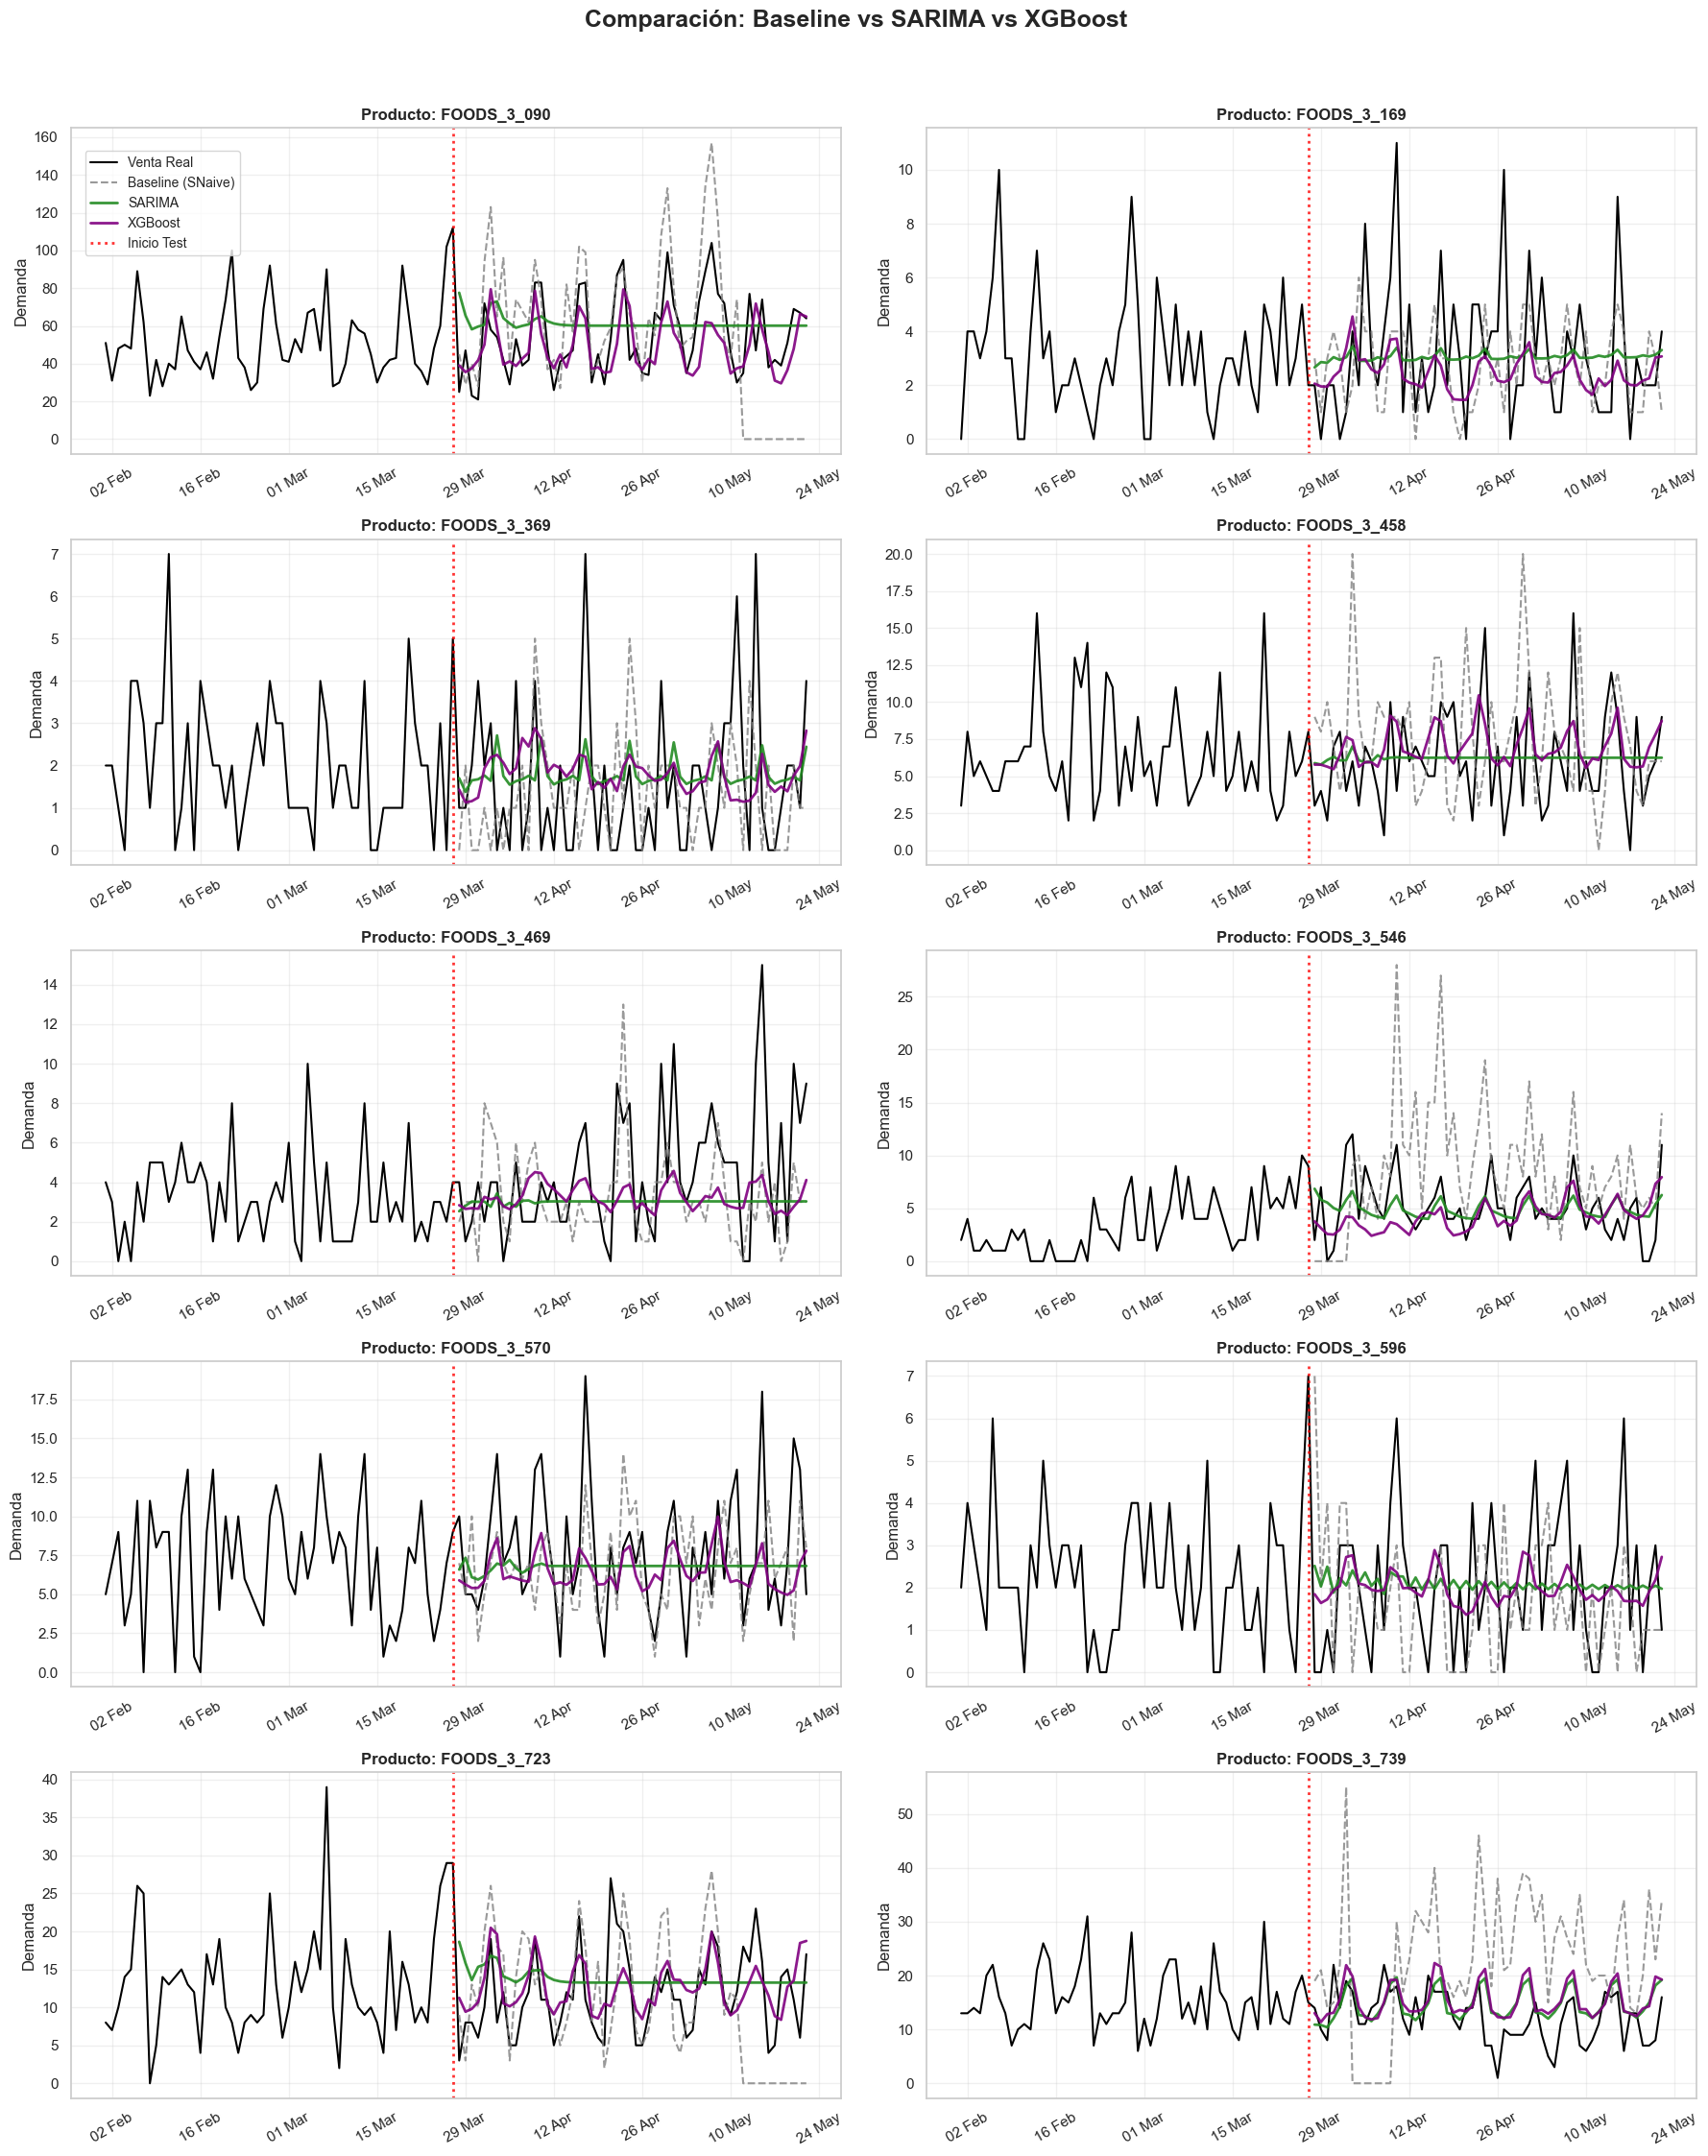

In [31]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# Obtenemos las últimas 8 semanas (56 días) del conjunto de Train
start_plot_date = cutoff_date - pd.Timedelta(days=56)
history_plot = train_df[train_df['date'] > start_plot_date][['item_id', 'date', 'sales']].copy()

# En el periodo histórico no hay predicciones, así que rellenamos con vacios
history_plot['pred_snaive_anual'] = np.nan
history_plot['pred_sarima'] = np.nan
history_plot['pred_xgb_global'] = np.nan

# Columnas relevantes de nuestro DataFrame de resultados (Test)
test_plot = resultados_finales[['item_id', 'date', 'sales', 'pred_snaive_anual', 
                                'pred_sarima', 'pred_xgb_global']].copy()

# Unimos ambos periodos para tener las 16 semanas continuas
plot_df = pd.concat([history_plot, test_plot], ignore_index=True)
plot_df = plot_df.sort_values(by=['item_id', 'date'])

## Graficos
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(18, 22))
axes = axes.flatten()

productos = plot_df['item_id'].unique()

for i, prod_id in enumerate(productos):
    ax = axes[i]
    
    # Filtramos los datos por producto
    df_prod = plot_df[plot_df['item_id'] == prod_id]
    
    # Línea de ventas reales (historico + test)
    ax.plot(df_prod['date'], df_prod['sales'], label='Venta Real', color='black', linewidth=1.5)
    
    # Líneas de pronóstico
    ax.plot(df_prod['date'], df_prod['pred_snaive_anual'], label='Baseline (SNaive)', color='gray', linestyle='--', alpha=0.8)
    ax.plot(df_prod['date'], df_prod['pred_sarima'], label='SARIMA', color='forestgreen', linewidth=2, alpha=0.9) # Azul
    ax.plot(df_prod['date'], df_prod['pred_xgb_global'], label='XGBoost', color='purple', linewidth=2, alpha=0.9) # Verde
    
    # Línea vertical para dividir claramente Train y Test
    ax.axvline(x=cutoff_date, color='red', linestyle=':', alpha=0.8, linewidth=2, label='Inicio Test')
    
    ax.set_title(f'Producto: {prod_id}', fontsize=12, weight='bold')
    ax.set_ylabel('Demanda')
    ax.grid(True, alpha=0.3)
    
    # Ajustamos las fechas del eje x para fácil lectura
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.tick_params(axis='x', rotation=30)
    
    # Mostrar la leyenda solo en el primer gráfico para mantenerlo limpio
    if i == 0:
        ax.legend(loc='upper left', fontsize=10, bbox_to_anchor=(0.01, 0.95))

plt.suptitle('Comparación: Baseline vs SARIMA vs XGBoost', y=1.02, fontsize=18, weight='bold')
plt.tight_layout()
plt.show()

## Grafico con solo dos productos

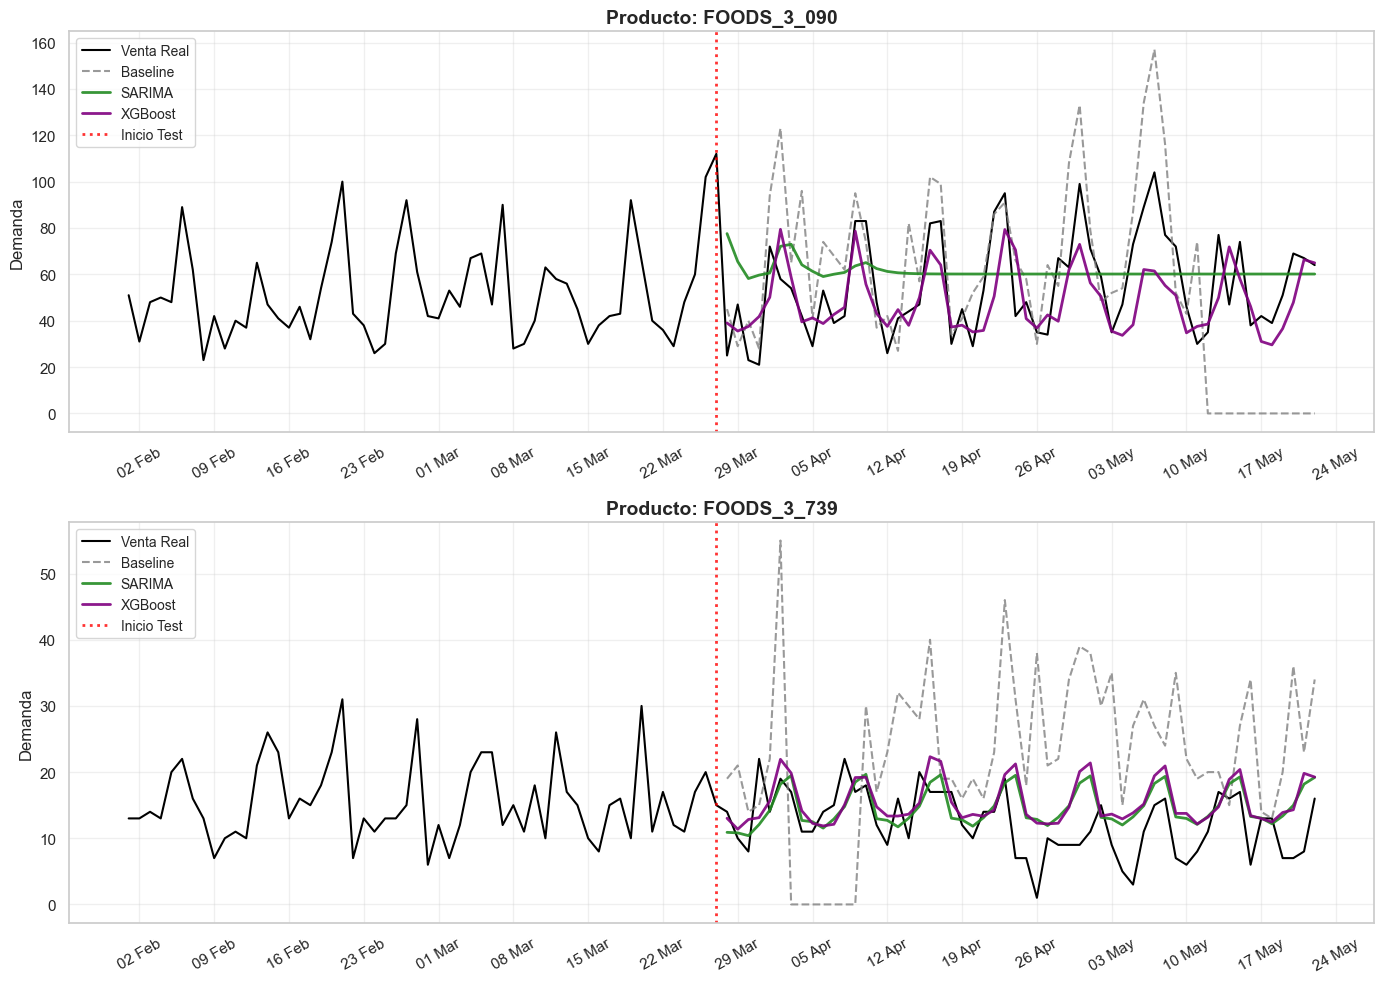

In [33]:
productos_top = ['FOODS_3_090', 'FOODS_3_739'] 

# Reconstruir el DataFrame de ploteo (Historia + Test)
start_plot_date = cutoff_date - pd.Timedelta(days=56)

# Historia 
history_plot = train_df[(train_df['date'] > start_plot_date) & (train_df['item_id'].isin(productos_top))].copy()
history_plot['pred_snaive_anual'] = np.nan
history_plot['pred_sarima'] = np.nan
history_plot['pred_xgb_global'] = np.nan

# Test
test_plot = resultados_finales[resultados_finales['item_id'].isin(productos_top)][
    ['item_id', 'date', 'sales', 'pred_snaive_anual', 'pred_sarima', 'pred_xgb_global']
].copy()

# Unir y ordenar
plot_df = pd.concat([history_plot, test_plot], ignore_index=True)
plot_df = plot_df.sort_values(by=['item_id', 'date'])

# Crear la cuadrícula de subgráficos (2 filas x 1 columna)
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 10))
axes = axes.flatten()

for i, prod_id in enumerate(productos_top):
    ax = axes[i]
    df_prod = plot_df[plot_df['item_id'] == prod_id]
    
    # Venta Real
    ax.plot(df_prod['date'], df_prod['sales'], label='Venta Real', color='black', linewidth=1.5)
    
    # Modelos
    ax.plot(df_prod['date'], df_prod['pred_snaive_anual'], label='Baseline', color='gray', linestyle='--', alpha=0.8)
    ax.plot(df_prod['date'], df_prod['pred_sarima'], label='SARIMA', color='forestgreen', linewidth=2, alpha=0.9)
    ax.plot(df_prod['date'], df_prod['pred_xgb_global'], label='XGBoost', color='purple', linewidth=2, alpha=0.9)
    
    # Línea divisoria Train/Test
    ax.axvline(x=cutoff_date, color='red', linestyle=':', alpha=0.8, linewidth=2, label='Inicio Test')
    
    # Estética
    ax.set_title(f'Producto: {prod_id}', fontsize=14, weight='bold')
    ax.set_ylabel('Demanda')
    ax.grid(True, alpha=0.3)
    
    # Formato de fechas (etiquetas cada semana)
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1)) 
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b')) 
    ax.tick_params(axis='x', rotation=30)
    
    # Leyenda
    ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()